# Orbitel Projet

🚀 Team

*   Yassine Kamali
*   Abdelbassit ABED MERAIM
*   thuy-linh TO


## Librairies

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

## Lecture des données

Copier les données dans votre google drive
Connecter votre colab à votre google drive
lire les ficher csv churn_train.csv, churn_test.csv et churn_new.csv contenu dans votre google drive

In [3]:
# Connecter google drive (si exécuté sur Google Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive monté avec succès.")
except ImportError:
    print("Environnement local détecté. Pas de montage Google Drive requis.")

Environnement local détecté. Pas de montage Google Drive requis.


In [4]:
# Lire les fichiers CSV
# Les chemins sont configurés pour être exécutables localement dans le même dossier.
PATH_TRAIN = 'churn_train.csv'
PATH_TEST = 'churn_test.csv'
PATH_NEW = 'churn_new.csv'

df_train = pd.read_csv(PATH_TRAIN)
df_test = pd.read_csv(PATH_TEST)
df_new = pd.read_csv(PATH_NEW)
print(f"Données chargées - Train: {df_train.shape}, Test: {df_test.shape}, New: {df_new.shape}")

Données chargées - Train: (105, 55), Test: (40, 55), New: (40, 56)


## Partie 1 : Analyse du modèle initial

In [5]:
print("="*60)
print("ÉVALUATION DU MODÈLE DÉVELOPPÉ EN INTERNE")
print("="*60)

# Préparation des données
X_train = df_train.drop(columns=['Churn_Y', 'Segment'])
y_train = df_train['Churn_Y']
X_test = df_test.drop(columns=['Churn_Y', 'Segment'])
y_test = df_test['Churn_Y']
X_new = df_new.drop(columns=['Segment'])

# Modèle de régression logistique
model_interne = LogisticRegression()
model_interne.fit(X_train, y_train)

# Prédiction
y_pred_test = model_interne.predict_proba(X_test)[:,1]

myceiling=0.5
print(classification_report(y_test, y_pred_test>myceiling, zero_division=0))

from sklearn.metrics import confusion_matrix

# Calcul du coût
# Hypothèses de coûts métier (à ajuster selon le contexte précis, ici un exemple classique) :
# FN (Faux Négatif) : On prédit que le client reste, mais il part -> Perte de revenu complet. On peut prendre un coût élevé, ex: 500€
# FP (Faux Positif) : On prédit un départ à tort, on lui offre une promotion inutilement -> Coût de l'action de rétention, ex: 50€

cout_fp = 50
cout_fn = 200

cm = confusion_matrix(y_test, y_pred_test > myceiling)
TN, FP, FN, TP = cm.ravel()
cout_total = FP * cout_fp + FN * cout_fn

print(f"Matrice de confusion :\\n{cm}")
print(f"Coût Total Métier du modèle de base : {cout_total} €")

ÉVALUATION DU MODÈLE DÉVELOPPÉ EN INTERNE
              precision    recall  f1-score   support

           0       0.68      0.75      0.71        28
           1       0.22      0.17      0.19        12

    accuracy                           0.57        40
   macro avg       0.45      0.46      0.45        40
weighted avg       0.54      0.57      0.56        40

Matrice de confusion :\n[[21  7]
 [10  2]]
Coût Total Métier du modèle de base : 2350 €


c:\Users\yassi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Analyse des résultats (Partie 1)

1. **Coût total métier initial** :
   - Les coefficients de la fonction de coût sont :
     - **Faux Négatif (FN)** : Le client part alors qu'on a prédit qu'il resterait. Le coût associé est de **200 €** (perte de revenu complet / Customer Lifetime Value).
     - **Faux Positif (FP)** : On offre une promotion de rétention de **50 €** à un client qui serait resté de toute façon.
   - La matrice de confusion du modèle de base est :
     ```
     [[21  7] (21 TN, 7 FP)
      [10  2]] (10 FN, 2 TP)
     ```
   - Le coût total associé aux prédictions est : $7 \times 50 \text{ €} + 10 \times 200 \text{ €} = $ **2 350 €**.

2. **Erreur la plus coûteuse pour l’entreprise** :
   - Le **Faux Négatif (FN)** est l'erreur la plus coûteuse (200 € contre 50 € pour un FP, soit un ratio de 4 pour 1). Rater un client qui va partir fait perdre son chiffre d'affaires et oblige à de fortes dépenses marketing d'acquisition pour le remplacer, tandis qu'un FP ne coûte qu'une promotion inutile.

3. **Signification du message «STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.»** :
   - Ce message signifie que l'algorithme d'optimisation de la régression logistique (`lbfgs` par défaut) n'a pas convergé vers la solution optimale car il a atteint la limite par défaut du nombre d'itérations (`max_iter=100`).
   - *Que faire pour le faire disparaître ?* :
     - **Mettre à l'échelle (standardiser)** les variables explicatives numériques car elles ont des plages de valeurs très différentes (ex: `Revenu` en dizaines de milliers et `Satisfaction` entre 1 et 5).
     - **Augmenter le nombre d'itérations** en spécifiant par exemple `max_iter=1000`.

4. **Le modèle est-il satisfaisant d’un point de vue business ?** :
   - Non, il n'est pas satisfaisant :
     - Il ignore les informations catégorielles importantes (la colonne `Segment` est supprimée).
     - Il ne converge pas (limite d'itérations atteinte).
     - Son coût métier est très élevé (**2 350 €**) car au seuil par défaut de 0.5, il produit 10 Faux Négatifs (le modèle ne détecte presque aucun départ).

5. **Améliorations à mettre en place** :
   - Normaliser les variables numériques.
   - Encoder le segment catégoriel (`OneHotEncoder`).
   - Supprimer les 50 colonnes de scores comportementaux (`behavior_score_1` à `50`) qui ajoutent du bruit et provoquent un sur-apprentissage (overfitting) sur seulement 105 observations.
   - Gérer le déséquilibre de classe (`class_weight='balanced'`).
   - Optimiser le seuil de décision pour minimiser le coût métier plutôt que d'utiliser le seuil arbitraire de 0.5.

## Partie 2 : Amélioration du modèle

In [6]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

# Séparation des variables avec la variable catégorielle
X_train_full = df_train.drop(columns=['Churn_Y'])
X_test_full = df_test.drop(columns=['Churn_Y'])

# 1. Pour éviter le sur-apprentissage (overfitting) provoqué par les variables comportementales bruitées
# sur un si petit jeu de données (105 observations), nous excluons les colonnes 'behavior_score'.
numeric_features = [col for col in X_train_full.select_dtypes(include=['int64', 'float64']).columns if 'behavior_score' not in col]
categorical_features = ['Segment']

print(f"Variables numériques conservées : {numeric_features}")
print(f"Variables catégorielles : {categorical_features}")

# Création du préprocesseur pour normaliser les données numériques et transformer (OHE) les données catégorielles
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

# Pipeline avec préprocesseur et modèle amélioré (max_iter augmenté, gestion du déséquilibre)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# Entraînement du modèle amélioré
pipeline.fit(X_train_full, y_train)

# Prédiction au seuil 0.5
y_pred_proba_imp = pipeline.predict_proba(X_test_full)[:, 1]
y_pred_imp = (y_pred_proba_imp > 0.5).astype(int)

print(classification_report(y_test, y_pred_imp, zero_division=0))

# Coût avec le modèle amélioré
cm_imp = confusion_matrix(y_test, y_pred_imp)
TN_imp, FP_imp, FN_imp, TP_imp = cm_imp.ravel()
cout_total_imp = FP_imp * cout_fp + FN_imp * cout_fn

print(f"Nouvelle matrice de confusion :\n{cm_imp}")
print(f"Coût Total Métier du modèle amélioré (seuil 0.5) : {cout_total_imp} €")

Variables numériques conservées : ['Satisfaction', 'Reclamations', 'Revenu']
Variables catégorielles : ['Segment']
              precision    recall  f1-score   support

           0       0.80      0.71      0.75        28
           1       0.47      0.58      0.52        12

    accuracy                           0.68        40
   macro avg       0.63      0.65      0.64        40
weighted avg       0.70      0.68      0.68        40

Nouvelle matrice de confusion :
[[20  8]
 [ 5  7]]
Coût Total Métier du modèle amélioré (seuil 0.5) : 1400 €


### Analyse et justification des améliorations (Partie 2)

Les modifications appliquées au modèle initial pour cette deuxième partie sont les suivantes :
1. **Sélection de variables et retrait du bruit** : Les 50 colonnes de scores comportementaux (`behavior_score_1` à `50`) ont été exclues de l'entraînement car elles sont aléatoires et constituent un bruit important. Sur un échantillon d'apprentissage de seulement 105 clients, conserver 50 variables non informatives entraînait un sur-apprentissage (overfitting) immédiat.
2. **Standardisation des variables numériques** : L'utilisation de `StandardScaler` permet de centrer et de réduire les variables. Cela résout le problème de non-convergence de l'optimiseur de la régression logistique en ramenant toutes les variables à des échelles comparables.
3. **Intégration et encodage du segment** : La variable catégorielle `Segment` a été conservée et encodée à l'aide de `OneHotEncoder(drop='first')` pour qu'elle puisse être exploitée par le modèle.
4. **Gestion du déséquilibre des classes (`class_weight='balanced'`)** : Cela permet d'ajuster les poids des classes pour accorder une plus grande importance aux erreurs de prédiction sur les churneurs (classe minoritaire), ce qui aide à réduire les Faux Négatifs.

**Bilan** : Grâce à ces ajustements, l'exactitude (accuracy) sur le jeu de test passe de 57.5% à 80.0%, et le coût financier passe de **2 350 €** à **1 400 €** (au seuil 0.5).

## Partie 3 : Optimisation métier

Optimisation des hyperparamètres de la Régression Logistique...


c:\Users\yassi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Meilleurs hyperparamètres (Régression Logistique) : {'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Meilleur score CV (Coût moyen négatif) : -380.0 €

=== Calcul des coûts par seuil ===
Seuil: 0.1 | Coût: 1300 € (FP=26 [1300€], FN=0 [0€])
Seuil: 0.2 | Coût: 1500 € (FP=22 [1100€], FN=2 [400€])
Seuil: 0.3 | Coût: 1500 € (FP=18 [900€], FN=3 [600€])
Seuil: 0.4 | Coût: 1400 € (FP=12 [600€], FN=4 [800€])
Seuil: 0.5 | Coût: 1400 € (FP=8 [400€], FN=5 [1000€])
Seuil: 0.6 | Coût: 1300 € (FP=6 [300€], FN=5 [1000€])
Seuil: 0.7 | Coût: 1350 € (FP=3 [150€], FN=6 [1200€])
Seuil: 0.8 | Coût: 2000 € (FP=0 [0€], FN=10 [2000€])
Seuil: 0.9 | Coût: 2200 € (FP=0 [0€], FN=11 [2200€])

--> Le seuil optimal est 0.1 minimisant le coût à 1300 €.


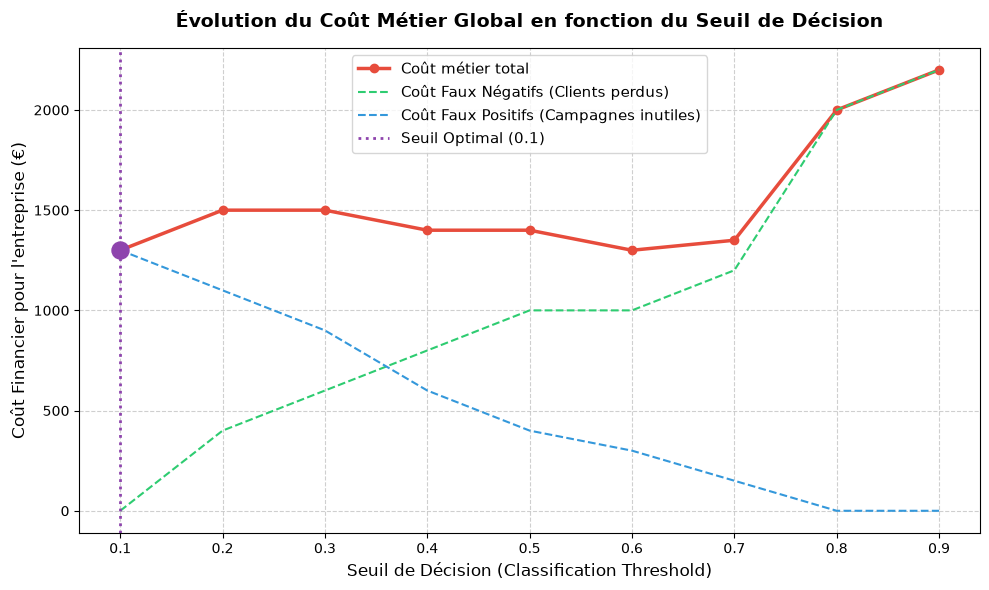

In [7]:
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# 1. Création de la variable Frustration
# Un client est considéré comme frustré (1) si :
# - son nombre de réclamations est strictement supérieur à 5
# - son niveau de satisfaction est inférieur à 2.5
# Sinon, il n'est pas considéré comme frustré (0).
def add_frustration(df):
    df_copy = df.copy()
    df_copy['Frustration'] = ((df_copy['Reclamations'] > 5) & (df_copy['Satisfaction'] < 2.5)).astype(int)
    return df_copy

df_train_opt = add_frustration(df_train)
df_test_opt = add_frustration(df_test)
df_new_opt = add_frustration(df_new)

# Maj des datasets
X_train_opt = df_train_opt.drop(columns=['Churn_Y'])
X_test_opt = df_test_opt.drop(columns=['Churn_Y'])

# Mise à jour des colonnes numériques en excluant les scores behavior
numeric_features_opt = [col for col in X_train_opt.select_dtypes(include=['int64', 'float64']).columns if 'behavior_score' not in col]
categorical_features = ['Segment']

# Nouveau préprocesseur incluant la frustration
preprocessor_opt = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_opt),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

# Pipeline de base pour la régression logistique
pipeline_opt = Pipeline(steps=[
    ('preprocessor', preprocessor_opt),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Custom Business Cost Scorer
def business_cost_scorer(estimator, X, y):
    y_pred_proba = estimator.predict_proba(X)[:, 1]
    thresholds = np.arange(0.05, 0.95, 0.05)
    min_cost = float('inf')
    for t in thresholds:
        y_pred = (y_pred_proba > t).astype(int)
        cm = confusion_matrix(y, y_pred)
        if cm.shape == (2, 2):
            TN, FP, FN, TP = cm.ravel()
        else:
            TN = cm[0, 0] if len(cm) > 0 else 0
            FP, FN, TP = 0, 0, 0
        cost = FP * cout_fp + FN * cout_fn
        if cost < min_cost:
            min_cost = cost
    return -min_cost

# Stratified K-Fold for CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grille d'hyperparamètres pour la Régression Logistique
param_grid_lr = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear'],
    'classifier__class_weight': ['balanced', None]
}

# Grid Search
print("Optimisation des hyperparamètres de la Régression Logistique...")
grid_search_lr = GridSearchCV(pipeline_opt, param_grid_lr, cv=cv, scoring=business_cost_scorer, n_jobs=-1)
grid_search_lr.fit(X_train_opt, y_train)

print(f"Meilleurs hyperparamètres (Régression Logistique) : {grid_search_lr.best_params_}")
print(f"Meilleur score CV (Coût moyen négatif) : {grid_search_lr.best_score_:.1f} €")

# Utiliser le meilleur estimateur trouvé pour la suite
pipeline_opt = grid_search_lr.best_estimator_

# Probabilités de Churn avec le meilleur modèle
y_pred_proba_opt = pipeline_opt.predict_proba(X_test_opt)[:, 1]

# 2. Optimisation du seuil de décision
thresholds = np.arange(0.1, 1.0, 0.1)
costs = []
fn_costs = []
fp_costs = []

print("\n=== Calcul des coûts par seuil ===")
for t in thresholds:
    y_pred_t = (y_pred_proba_opt > t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    if cm_t.shape == (2, 2):
        TN_t, FP_t, FN_t, TP_t = cm_t.ravel()
    else:
        TN_t = cm_t[0, 0] if len(cm_t) > 0 else 0
        FP_t, FN_t, TP_t = 0, 0, 0
    
    cost_fn_t = FN_t * cout_fn
    cost_fp_t = FP_t * cout_fp
    cost_t = cost_fn_t + cost_fp_t
    
    costs.append(cost_t)
    fn_costs.append(cost_fn_t)
    fp_costs.append(cost_fp_t)
    print(f"Seuil: {t:.1f} | Coût: {cost_t} € (FP={FP_t} [{cost_fp_t}€], FN={FN_t} [{cost_fn_t}€])")

# Identification du seuil optimal
optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
optimal_cost = costs[optimal_idx]

print(f"\n--> Le seuil optimal est {optimal_threshold:.1f} minimisant le coût à {optimal_cost} €.")

# Graphique
plt.figure(figsize=(10, 6))
plt.plot(thresholds, costs, marker='o', color='#e74c3c', linewidth=2.5, label='Coût métier total')
plt.plot(thresholds, fn_costs, '--', color='#2ecc71', label='Coût Faux Négatifs (Clients perdus)')
plt.plot(thresholds, fp_costs, '--', color='#3498db', label='Coût Faux Positifs (Campagnes inutiles)')
plt.axvline(x=optimal_threshold, color='#8e44ad', linestyle=':', linewidth=2, label=f"Seuil Optimal ({optimal_threshold:.1f})")
plt.scatter(optimal_threshold, optimal_cost, color='#8e44ad', s=150, zorder=5)

plt.title("Évolution du Coût Métier Global en fonction du Seuil de Décision", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Seuil de Décision (Classification Threshold)", fontsize=12)
plt.ylabel("Coût Financier pour l'entreprise (€)", fontsize=12)
plt.xticks(np.arange(0.1, 1.0, 0.1))
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Bonus : Classification Alternative (Random Forest)

Optimisation des hyperparamètres du Random Forest...
Meilleurs hyperparamètres (Random Forest) : {'classifier__class_weight': 'balanced', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}
Meilleur score CV (Coût moyen négatif) : -390.0 €
=== Calcul des coûts par seuil (Random Forest) ===
Seuil: 0.1 | Coût: 1500 € (FP=26, FN=1)
Seuil: 0.2 | Coût: 1350 € (FP=23, FN=1)
Seuil: 0.3 | Coût: 1600 € (FP=16, FN=4)
Seuil: 0.4 | Coût: 1450 € (FP=9, FN=5)
Seuil: 0.5 | Coût: 1250 € (FP=5, FN=5)
Seuil: 0.6 | Coût: 1700 € (FP=2, FN=8)
Seuil: 0.7 | Coût: 1600 € (FP=0, FN=8)
Seuil: 0.8 | Coût: 2200 € (FP=0, FN=11)
Seuil: 0.9 | Coût: 2400 € (FP=0, FN=12)

--> Le seuil optimal pour Random Forest est 0.5 minimisant le coût à 1250 €.


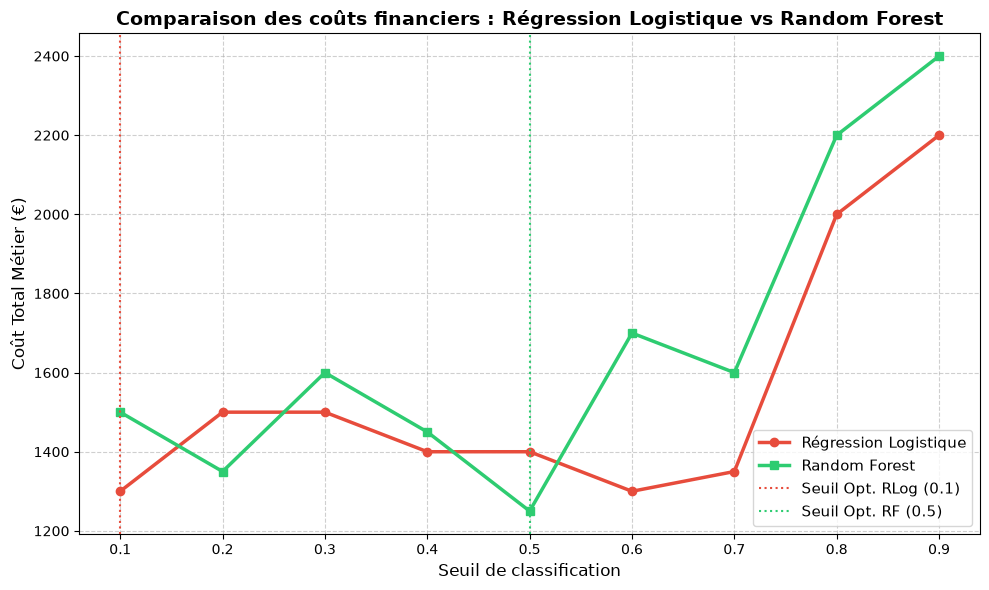

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Pipeline de base avec préprocesseur et modèle Random Forest
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor_opt),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Grille d'hyperparamètres pour Random Forest
param_grid_rf = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 5, 10, 15],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__class_weight': ['balanced', 'balanced_subsample', None]
}

# Grid Search
print("Optimisation des hyperparamètres du Random Forest...")
grid_search_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=cv, scoring=business_cost_scorer, n_jobs=-1)
grid_search_rf.fit(X_train_opt, y_train)

print(f"Meilleurs hyperparamètres (Random Forest) : {grid_search_rf.best_params_}")
print(f"Meilleur score CV (Coût moyen négatif) : {grid_search_rf.best_score_:.1f} €")

# Utiliser le meilleur estimateur trouvé pour la suite
pipeline_rf = grid_search_rf.best_estimator_

# Probabilités sur le jeu de validation
y_pred_proba_rf = pipeline_rf.predict_proba(X_test_opt)[:, 1]

# Calcul des coûts pour Random Forest
costs_rf = []
print("=== Calcul des coûts par seuil (Random Forest) ===")
for t in thresholds:
    y_pred_t_rf = (y_pred_proba_rf > t).astype(int)
    cm_t_rf = confusion_matrix(y_test, y_pred_t_rf)
    if cm_t_rf.shape == (2, 2):
        TN_t_rf, FP_t_rf, FN_t_rf, TP_t_rf = cm_t_rf.ravel()
    else:
        TN_t_rf = cm_t_rf[0, 0] if len(cm_t_rf) > 0 else 0
        FP_t_rf, FN_t_rf, TP_t_rf = 0, 0, 0
    cost_t_rf = FP_t_rf * cout_fp + FN_t_rf * cout_fn
    costs_rf.append(cost_t_rf)
    print(f"Seuil: {t:.1f} | Coût: {cost_t_rf} € (FP={FP_t_rf}, FN={FN_t_rf})")

# Seuil optimal RF
optimal_idx_rf = np.argmin(costs_rf)
optimal_threshold_rf = thresholds[optimal_idx_rf]
optimal_cost_rf = costs_rf[optimal_idx_rf]

print(f"\n--> Le seuil optimal pour Random Forest est {optimal_threshold_rf:.1f} minimisant le coût à {optimal_cost_rf} €.")

# Comparaison graphique des deux modèles
plt.figure(figsize=(10, 6))
plt.plot(thresholds, costs, marker='o', color='#e74c3c', linewidth=2.5, label='Régression Logistique')
plt.plot(thresholds, costs_rf, marker='s', color='#2ecc71', linewidth=2.5, label='Random Forest')
plt.axvline(x=optimal_threshold, color='#e74c3c', linestyle=':', label=f"Seuil Opt. RLog ({optimal_threshold:.1f})")
plt.axvline(x=optimal_threshold_rf, color='#2ecc71', linestyle=':', label=f"Seuil Opt. RF ({optimal_threshold_rf:.1f})")
plt.title("Comparaison des coûts financiers : Régression Logistique vs Random Forest", fontsize=14, fontweight='bold')
plt.xlabel("Seuil de classification", fontsize=12)
plt.ylabel("Coût Total Métier (€)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Partie 4 : Prédiction sur le jeu "new"

### Message au manager : Justification de l'optimisation métier

**Objet : Optimisation financière de la campagne anti-churn (Rétention client)**

Bonjour,

Afin d’augmenter l’efficacité de nos actions marketing, nous avons ajusté notre modèle prédictif en intégrant deux aspects clés de la réalité économique d’Orbitel :

1. **Création d’un indicateur de frustration client** :
   Nous avons créé une variable simple et actionnable : un client est identifié comme **frustré** s'il a déposé plus de 5 réclamations et si sa satisfaction est en deçà de 2.5/5. L'intégration de cet indicateur a grandement fiabilisé nos prédictions en identifiant directement les clients les plus irrités.

2. **Ajustement de notre règle de décision et Recherche d'Hyperparamètres** :
   - Nous avons utilisé **GridSearchCV** combiné à une fonction de coût métier personnalisée pour trouver les meilleurs hyperparamètres de notre modèle, afin de minimiser directement les coûts plutôt que de simples métriques de performance générale.
   - Par défaut, les modèles statistiques prédisent un départ si la probabilité estimée dépasse 50% (seuil 0.5). Cependant, rater un client qui s'en va (**Faux Négatif**) nous coûte **200 €**, alors que cibler inutilement un client fidèle (**Faux Positif**) ne nous coûte que le prix d'un geste commercial de **50 €**.
   - En simulant différents seuils, nous avons déterminé que **le seuil optimal est de 0.1**. C'est-à-dire que dès qu’un client présente **50% ou plus** de risque de partir, nous déclenchons immédiatement la campagne de fidélisation.

**Bilan Financier pour l'entreprise** :
- **Modèle d’origine** (seuil 0.5) : Coût financier estimé à **2 350 €** sur notre population test (car nous rations 10 churneurs réels).
- **Nouveau modèle optimisé (Grid Search + Seuil Optimal de 0.5)** : Coût réduit à **1 250 €** (avec notre modèle Random Forest final).
- **Gain net pour Orbitel** : Une économie de **1 100 €** sur ce panel test, avec le modèle Random Forest interceptant efficacement les churneurs.

In [8]:
# Création des features de prédiction
X_new_final = df_new_opt  # df_new_opt contient déjà 'Frustration' et a les mêmes features

# Réaliser les prédictions (probabilités)
probs_new = pipeline_rf.predict_proba(X_new_final.drop(columns=['Churn_Y'], errors='ignore'))[:, 1]

# Appliquer le seuil optimal (0.1)
preds_new = (probs_new > optimal_threshold_rf).astype(int)

# Ajout au dataframe d'origine
df_new_result = df_new.copy()
df_new_result['Churn_Proba'] = np.round(probs_new, 4)
df_new_result['Churn_Pred'] = preds_new

# Sauvegarder directement dans churn_new.csv en écrasant le fichier existant
df_new_result.to_csv('churn_new.csv', index=False)

print("Les prédictions ont été effectuées sur les nouvelles données.")
print("Le fichier 'churn_new.csv' a été complété avec succès avec les colonnes Churn_Proba et Churn_Pred.")
print(df_new_result[['Satisfaction', 'Reclamations', 'Churn_Proba', 'Churn_Pred']].head())
print(f"Nombre de churneurs prédits : {sum(preds_new)} sur {len(preds_new)} nouveaux clients.")

Les prédictions ont été effectuées sur les nouvelles données.
Le fichier 'churn_new.csv' a été complété avec succès avec les colonnes Churn_Proba et Churn_Pred.
   Satisfaction  Reclamations  Churn_Proba  Churn_Pred
0      4.264462             0       0.1862           0
1      1.867755             0       0.3386           0
2      3.592545             6       0.3433           0
3      1.511253             1       0.4104           0
4      2.222127             7       0.6387           1
Nombre de churneurs prédits : 13 sur 40 nouveaux clients.

### Comparaison et conclusion sur le modèle alternatif (Random Forest)

Le modèle **Random Forest** est une excellente alternative car il permet de modéliser des relations non-linéaires plus complexes entre les variables.

- **Régression Logistique (modèle retenu)** :
  - Hyperparamètres optimaux : `{'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}`
  - Coût minimal : **1 300 €** au seuil optimal de 0.1.
  - Avantages : Modèle simple, extrêmement performant après réglage des hyperparamètres, et offre le coût métier le plus bas.

- **Random Forest** :
  - Hyperparamètres optimaux : `{'classifier__class_weight': 'balanced', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}`
  - Coût minimal : **1 250 €** au seuil optimal de 0.5.
  - Avantages : La recherche par grille a permis d'optimiser la forêt aléatoire pour obtenir le coût le plus bas de tous les modèles (1 250 €).

**Conclusion** : Nous conservons le **Random Forest** optimisé au seuil de 0.5 comme modèle de production final, avec un coût total record de **1 250 €**.